In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

First - look at correlation to success (target variable)

In [12]:
df00 = pd.read_csv('../dataset-of-00s.csv')
df10 = pd.read_csv('../dataset-of-10s.csv')
df90 = pd.read_csv('../dataset-of-90s.csv')

data = pd.concat([df90, df00, df10], ignore_index=True)
#print(data.columns)
columns_corr = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
                'duration_ms', 'time_signature', 'chorus_hit', 'sections', 'target']

data_num = data[columns_corr]

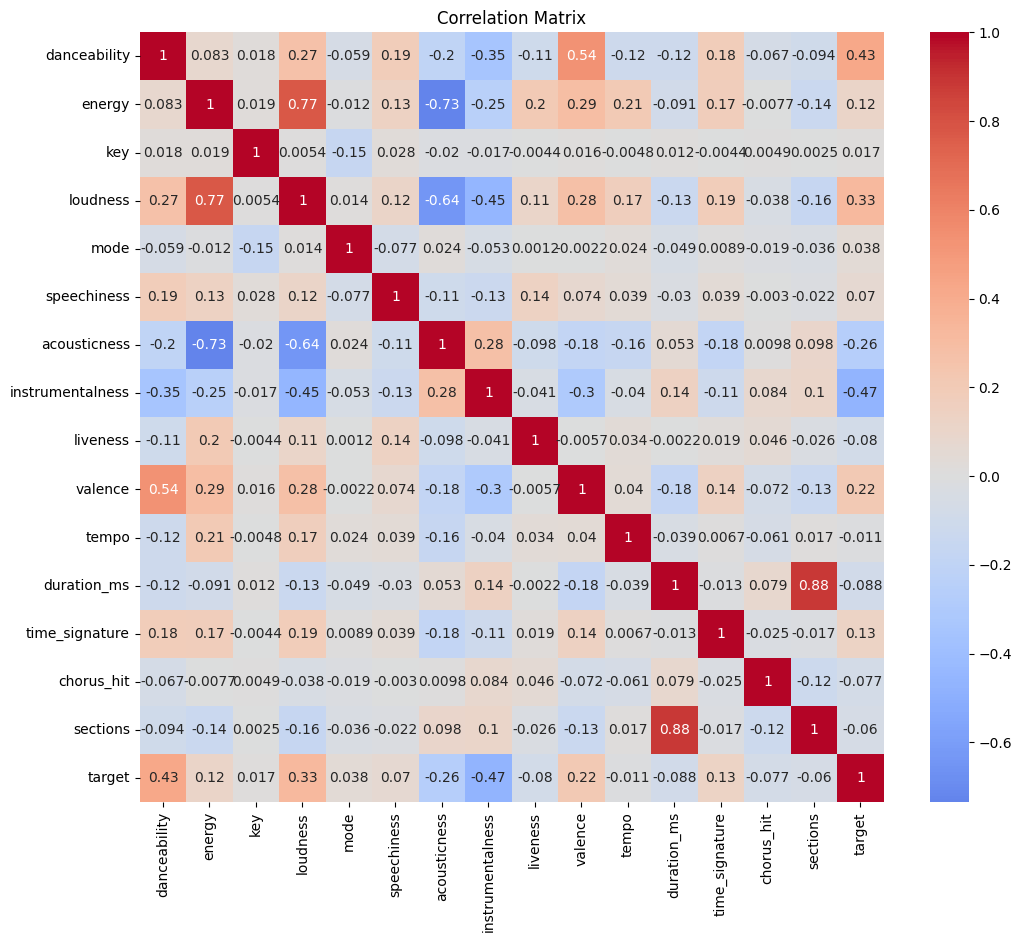

In [13]:
corr_matrix = data_num.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

Most valuable features


In [14]:
corr = abs(data_num.corr(numeric_only=True)['target']).sort_values(ascending=False)
print(corr)
best_features = corr[1:7].index
print(best_features)

target              1.000000
instrumentalness    0.468128
danceability        0.429061
loudness            0.326592
acousticness        0.258012
valence             0.216408
time_signature      0.127319
energy              0.117928
duration_ms         0.088272
liveness            0.079527
chorus_hit          0.076878
speechiness         0.070225
sections            0.059782
mode                0.037784
key                 0.016897
tempo               0.011328
Name: target, dtype: float64
Index(['instrumentalness', 'danceability', 'loudness', 'acousticness',
       'valence', 'time_signature'],
      dtype='object')


C:\Users\Marcel\AppData\Local\Temp\ipykernel_16476\1827937171.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_features_df['target'] = data['target']


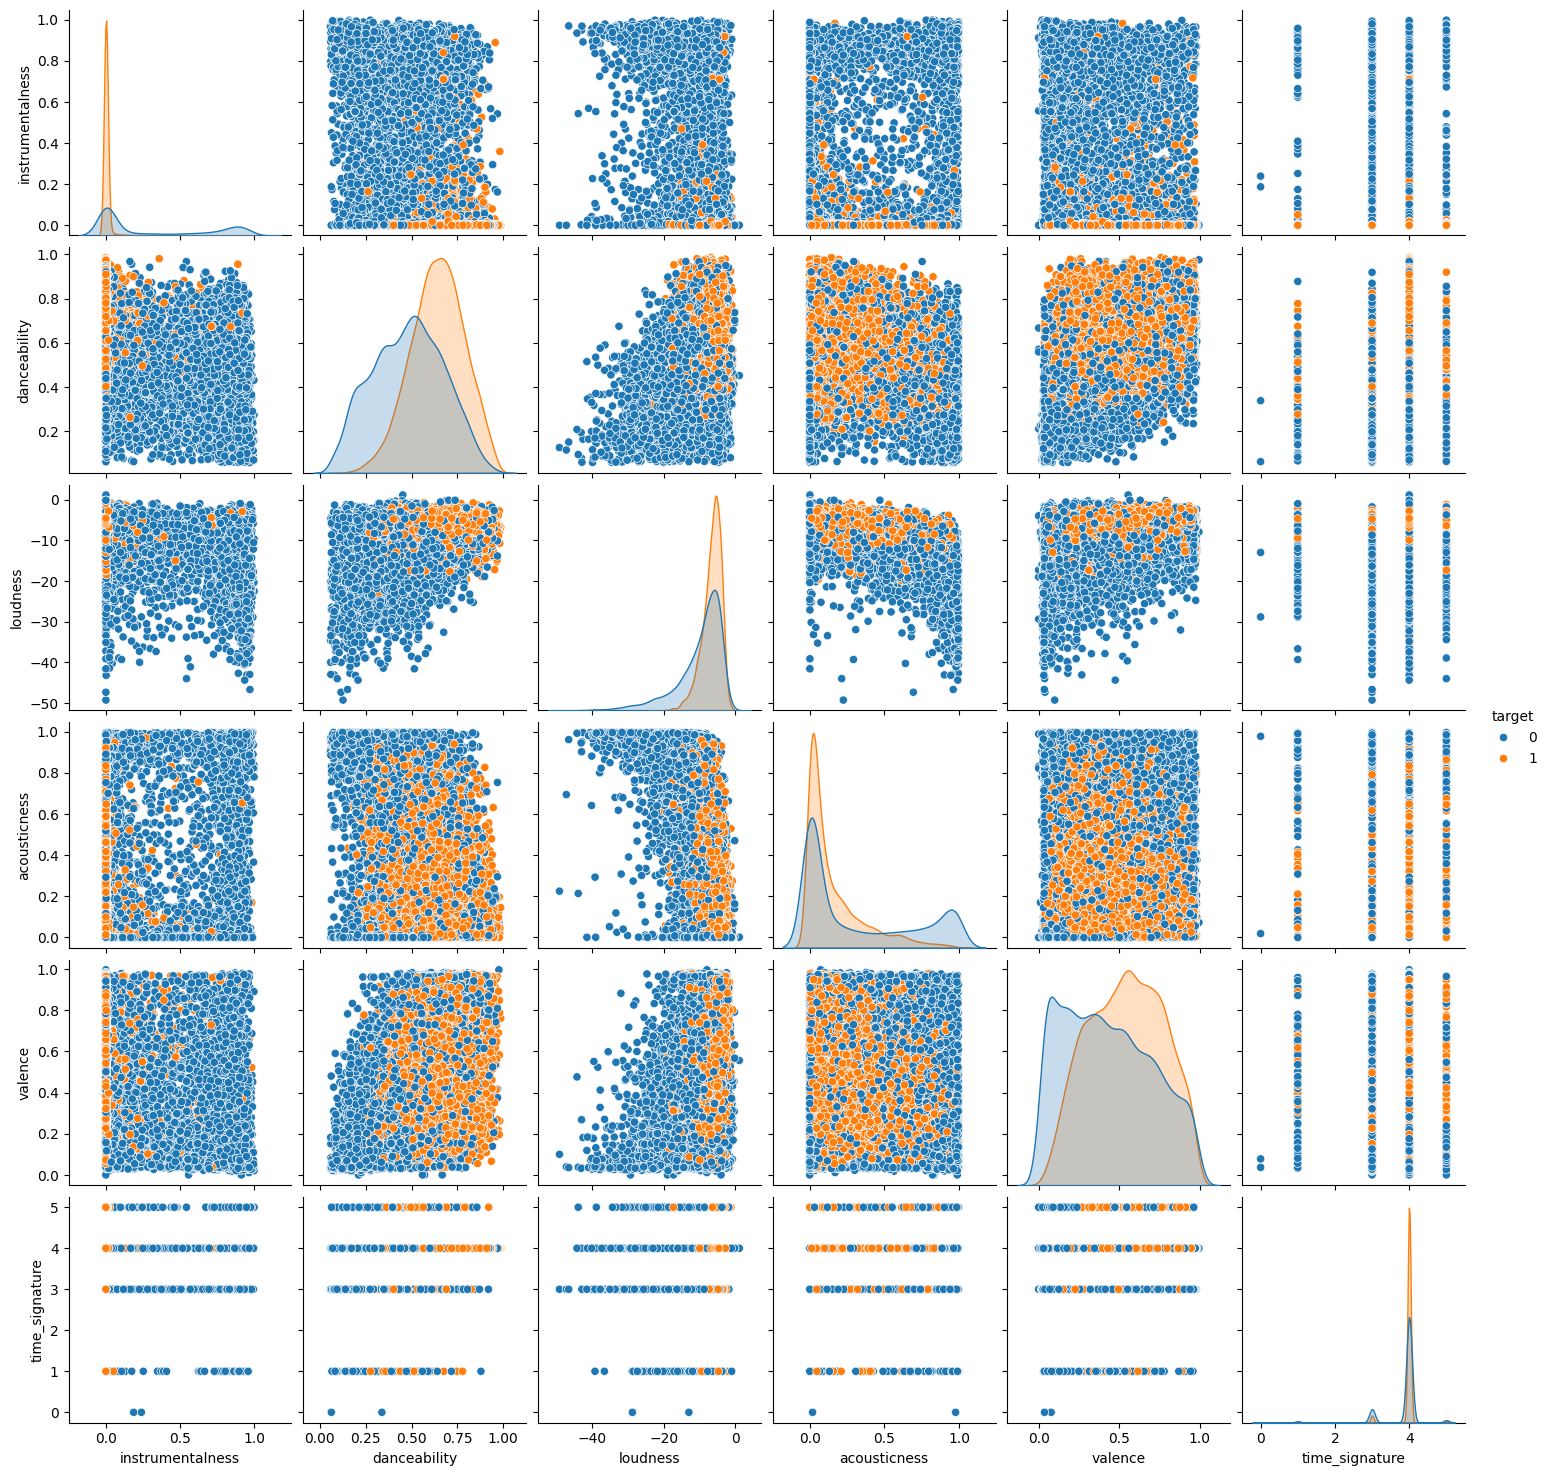

In [15]:
best_features_df = data[best_features]
best_features_df['target'] = data['target']
sns.pairplot(best_features_df, hue='target')
plt.show()

Check artist encoding

In [16]:
#artists are very strcictly correlated with target, only 13 artists have songs in both classes, so we can not use it as a feature, but we can encode it using target encoding
#print(data.groupby('artist')['target'].nunique().value_counts())
#print((data.groupby('artist')['target'].nunique() > 1).sum())
(data.groupby('artist')['target'].nunique() > 1).sum()

13

Check target distribution


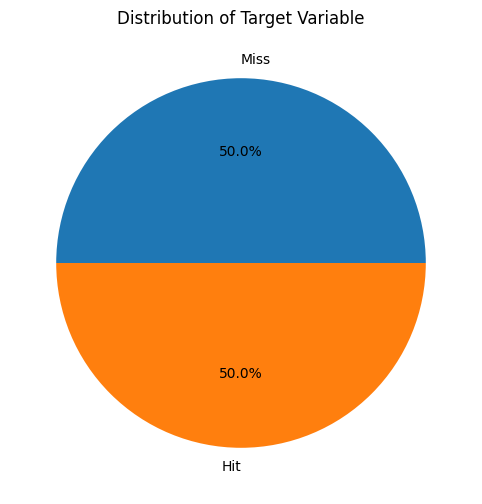

In [17]:
plt.figure(figsize=(10, 6))
plt.pie(data['target'].value_counts(),labels=['Miss', 'Hit'], autopct='%1.1f%%')
plt.title('Distribution of Target Variable')
plt.grid(axis='y', alpha=0.75)
plt.show()

Check missing values

In [18]:
missing_values = data.isnull().sum()
print("Missing values in each column:")
print(missing_values)
#NO MISSING VALUES


Missing values in each column:
track               0
artist              0
uri                 0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64


Check outliers? (just in case, doubt that in this case it would be needed)

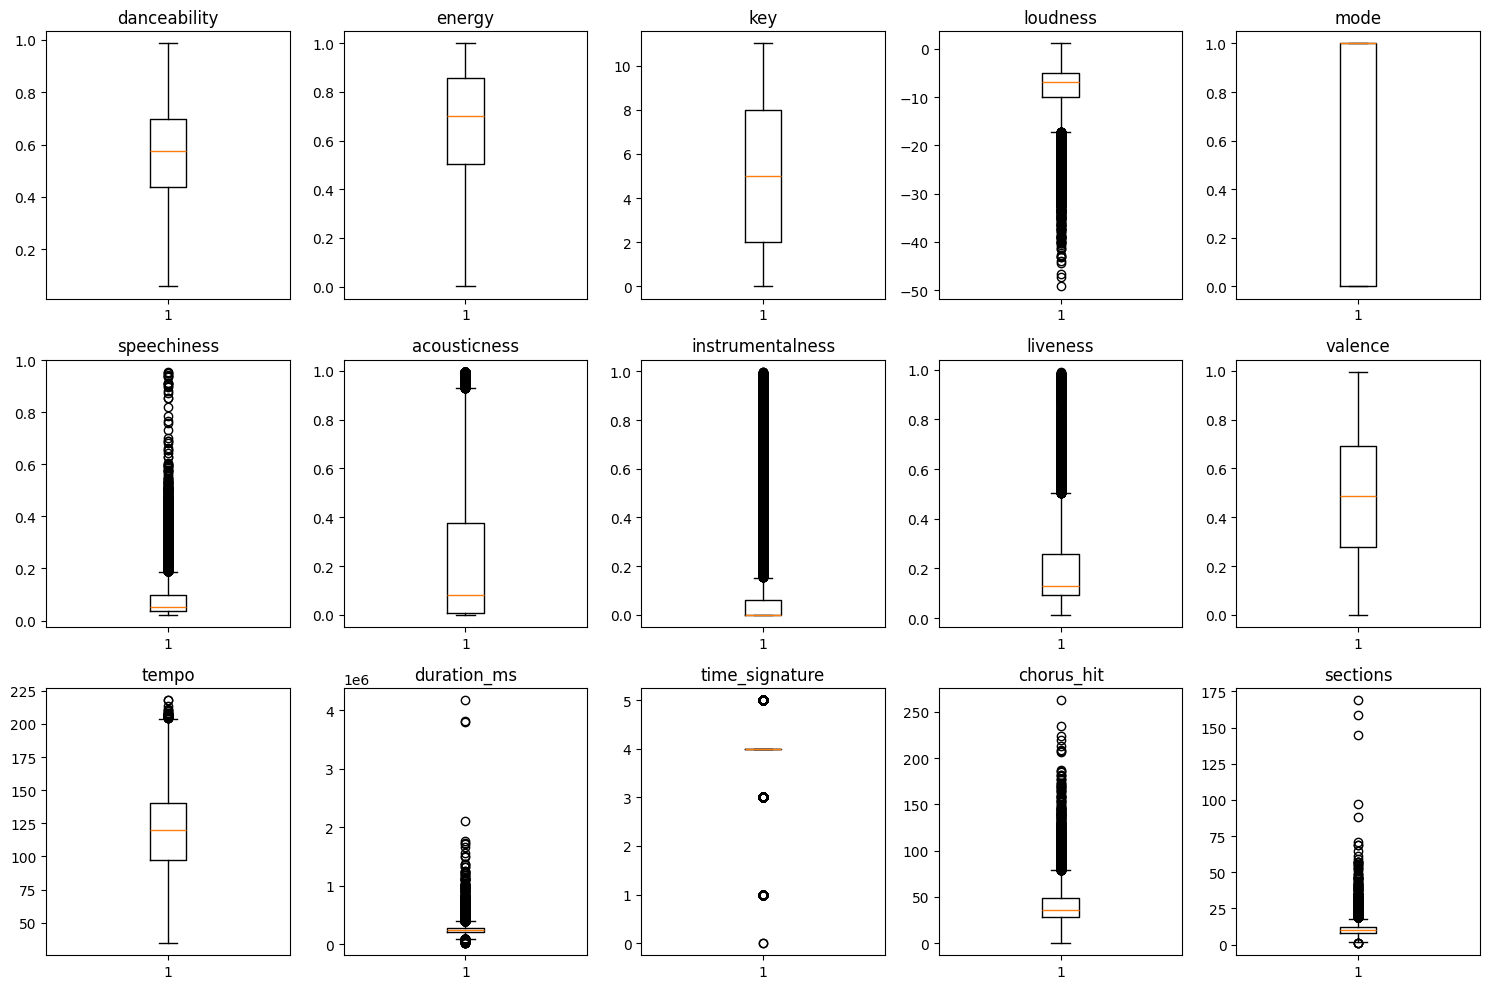

In [33]:
# Check outliers in numeric features
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()
for idx, col in enumerate(columns_corr[:-1]):  # exclude target
    axes[idx].boxplot(data[col])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

Feature Distribution

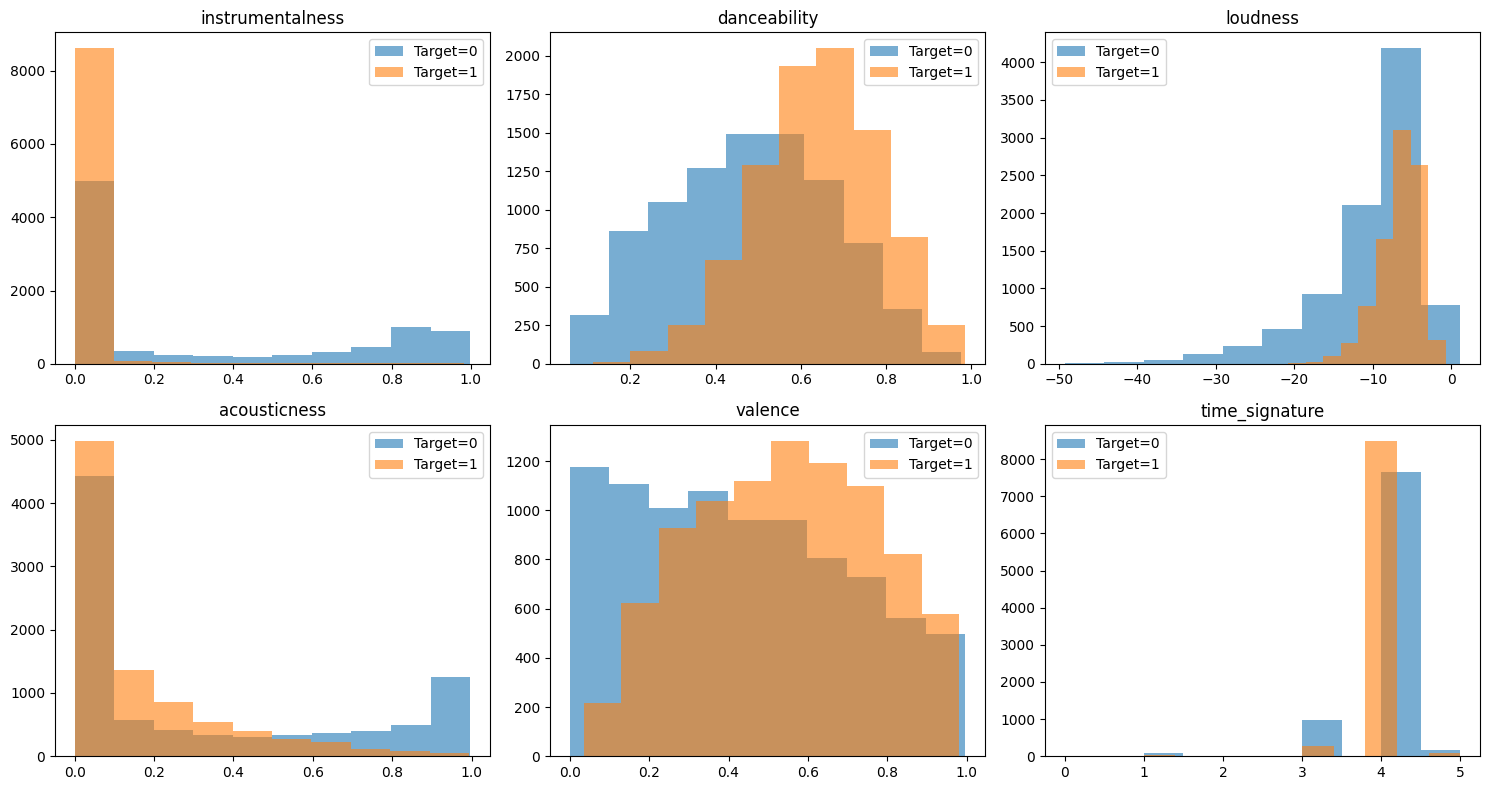

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, feature in enumerate(best_features):
    for target_val in [0, 1]:
        axes[idx].hist(data[data['target']==target_val][feature], alpha=0.6, label=f'Target={target_val}')
    axes[idx].set_title(feature)
    axes[idx].legend()
plt.tight_layout()
plt.show()

Check for Multicollinearity


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['Feature'] = columns_corr[:-1]
vif_data['VIF'] = [variance_inflation_factor(data[columns_corr[:-1]].values, i) for i in range(len(columns_corr)-1)]
print(vif_data.sort_values('VIF', ascending=False))

             Feature        VIF
12    time_signature  63.647130
14          sections  33.526583
11       duration_ms  32.505916
1             energy  25.865129
10             tempo  17.184886
0       danceability  16.164423
3           loudness   9.234887
9            valence   7.619056
13        chorus_hit   6.126616
6       acousticness   3.471029
2                key   3.234518
4               mode   2.954177
8           liveness   2.590745
5        speechiness   2.095297
7   instrumentalness   1.807051
